In [185]:
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris



In [186]:
df = load_iris()
X = df.data
y = df.target

In [187]:
df = pd.DataFrame(X, columns=df.feature_names)
df['target'] = y
df.head()

<IPython.core.display.Javascript object>

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [188]:
df.iloc[:,-1]

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int32

<Axes: xlabel='sepal width (cm)', ylabel='petal length (cm)'>

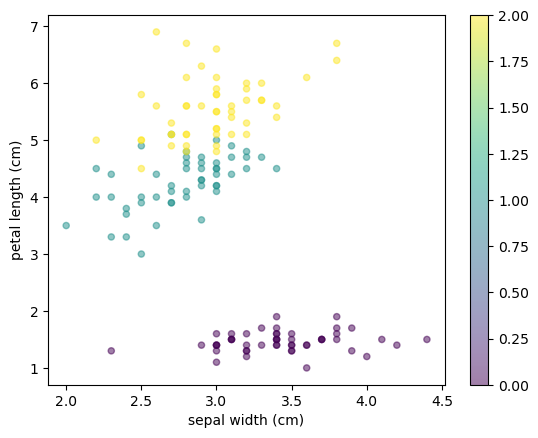

In [189]:
df.iloc[:,1:3].plot.scatter(x='sepal width (cm)', y='petal length (cm)', c=df.target, colormap='viridis', alpha=0.5)

In [190]:
df.shape

(150, 5)

In [191]:
df = df[df['target'] !=0 ][['sepal length (cm)','petal length (cm)', 'target']]

In [192]:
df.shape

(100, 3)

Text(0, 0.5, 'petal length (cm)')

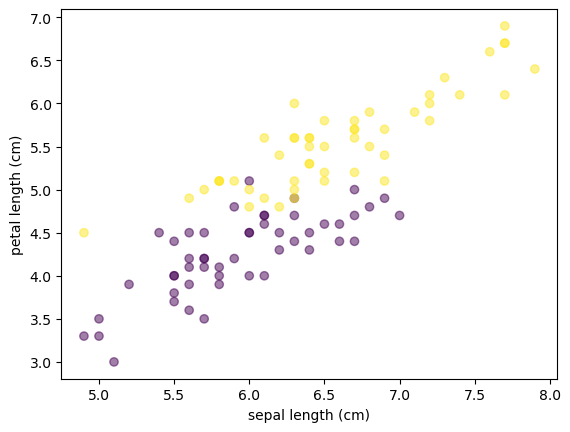

In [193]:
plt.scatter(df['sepal length (cm)'],df['petal length (cm)'], c=df['target'], cmap='viridis', alpha=0.5)
plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')

In [194]:
## taking only 10 rows for training and 10 rows for testing bagging
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [195]:
df_train

,sepal length (cm),petal length (cm),target
94,5.6,4.2,1
81,5.5,3.7,1
136,6.3,5.6,2
119,6.0,5.0,2
139,6.9,5.4,2
110,6.5,5.1,2
100,6.3,6.0,2
99,5.7,4.1,1
145,6.7,5.2,2
85,6.0,4.5,1


In [196]:
df_val

,sepal length (cm),petal length (cm),target
76,6.8,4.8,1
96,5.7,4.2,1
140,6.7,5.6,2
118,7.7,6.9,2
50,7.0,4.7,1


In [197]:
df_test

,sepal length (cm),petal length (cm),target
62,6.0,4.0,1
124,6.7,5.7,2
108,6.7,5.8,2
93,5.0,3.3,1
75,6.6,4.4,1


In [198]:
x_test = df_test.iloc[:,0:2].values
y_test = df_test.iloc[:,-1].values

In [218]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from mlxtend.classifier import StackingClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree

plot_decision_regions = plot_tree

## Case 1 - Bagging 

In [219]:


from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt
import numpy as np

def evaluate_model(model, X, y):
    model.fit(X, y)

    # Plot decision tree
    plt.figure(figsize=(12, 8))
    plot_tree(model, feature_names=X.columns, class_names=np.unique(y.astype(str)), filled=True)
    plt.show()

    # Plot decision regions (if 2D)
    if X.shape[1] == 2:
        plot_decision_regions(X.values, y.values, clf=model, legend=2)
        plt.xlabel(X.columns[0])
        plt.ylabel(X.columns[1])
        plt.title("Decision Regions")
        plt.show()

    # Accuracy
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    print("Accuracy: %.2f%%" % (accuracy * 100.0))


(8, 2)
(8,)
     sepal length (cm)  petal length (cm)  target
136                6.3                5.6       2
81                 5.5                3.7       1
119                6.0                5.0       2
145                6.7                5.2       2
85                 6.0                4.5       1
119                6.0                5.0       2
100                6.3                6.0       2
139                6.9                5.4       2


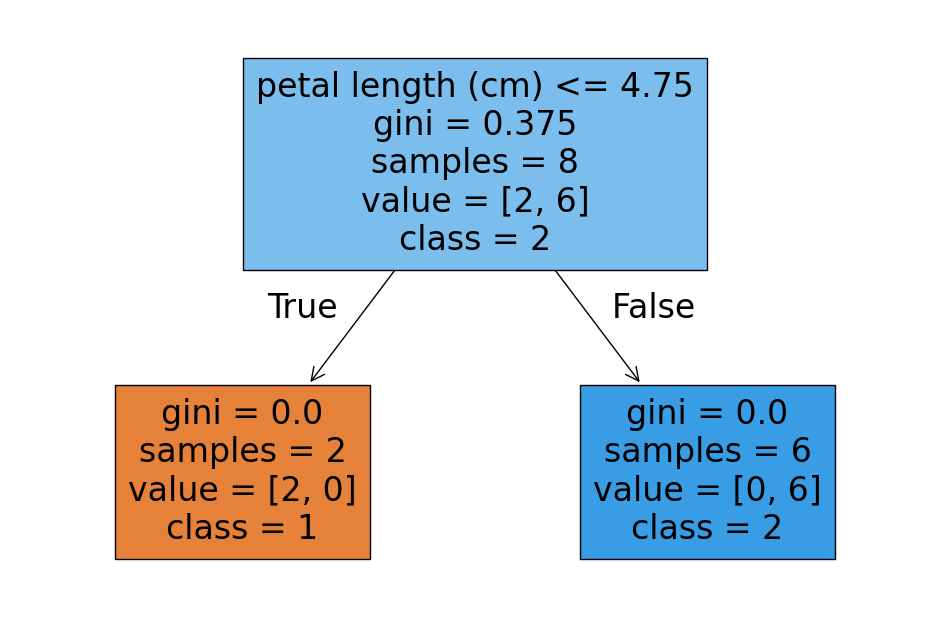

c:\Users\bhara\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


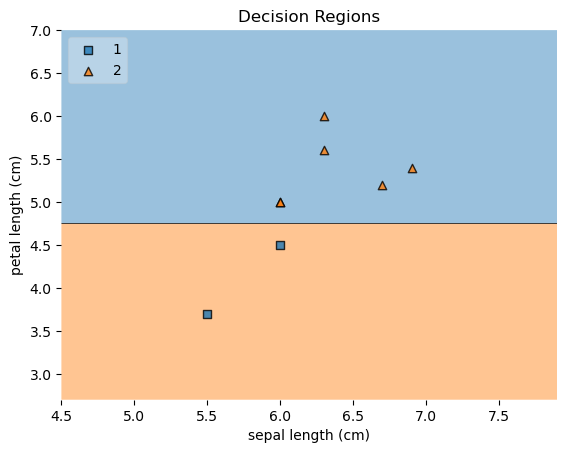

Accuracy: 100.00%


c:\Users\bhara\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [220]:
df_bag = df_train.sample(8, replace=True)
x_bag = df_bag.iloc[:,0:2]
y_bag = df_bag.iloc[:,-1]
print(x_bag.shape)
print(y_bag.shape)
print(df_bag)
clf1 = DecisionTreeClassifier()
evaluate_model(clf1, x_bag, y_bag)

(8, 2)
(8,)
     sepal length (cm)  petal length (cm)  target
85                 6.0                4.5       1
145                6.7                5.2       2
81                 5.5                3.7       1
119                6.0                5.0       2
136                6.3                5.6       2
85                 6.0                4.5       1
85                 6.0                4.5       1
139                6.9                5.4       2


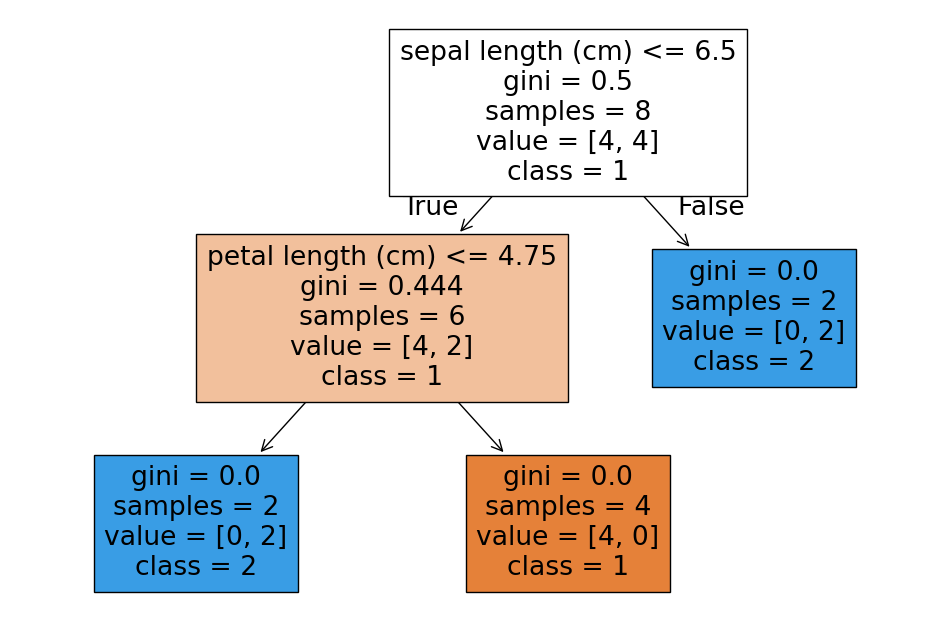

c:\Users\bhara\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


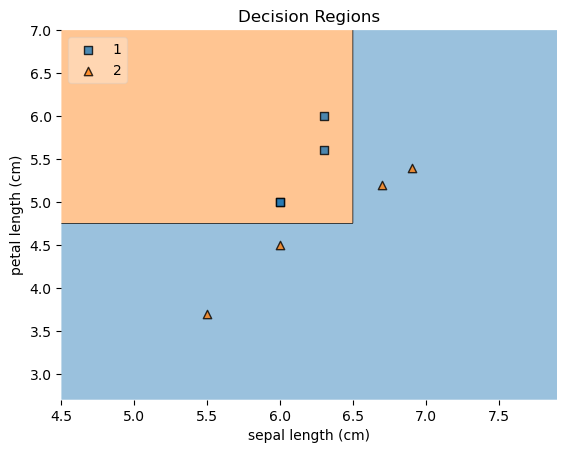

Accuracy: 40.00%


c:\Users\bhara\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [225]:
df_bag = df_train.sample(8, replace=True)
X_bag = df_bag.iloc[:,0:2]
y_bag = df_bag.iloc[:,-1]
print(X_bag.shape)
print(y_bag.shape)
print(df_bag)
clf2 = DecisionTreeClassifier()
evaluate_model(clf2, x_bag, y_bag)

(8, 2)
(8,)
     sepal length (cm)  petal length (cm)  target
139                6.9                5.4       2
139                6.9                5.4       2
81                 5.5                3.7       1
85                 6.0                4.5       1
85                 6.0                4.5       1
110                6.5                5.1       2
100                6.3                6.0       2
136                6.3                5.6       2


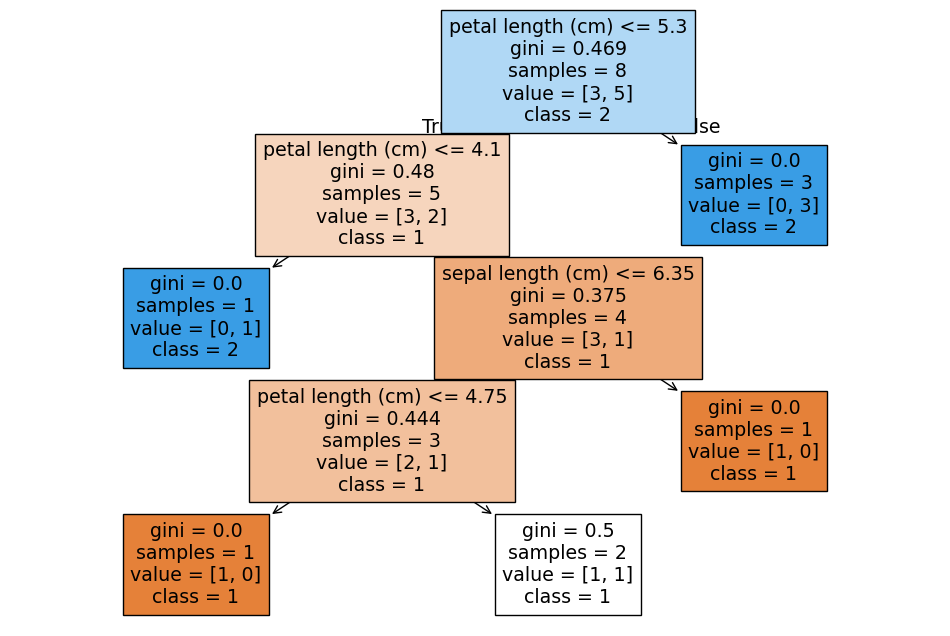

c:\Users\bhara\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


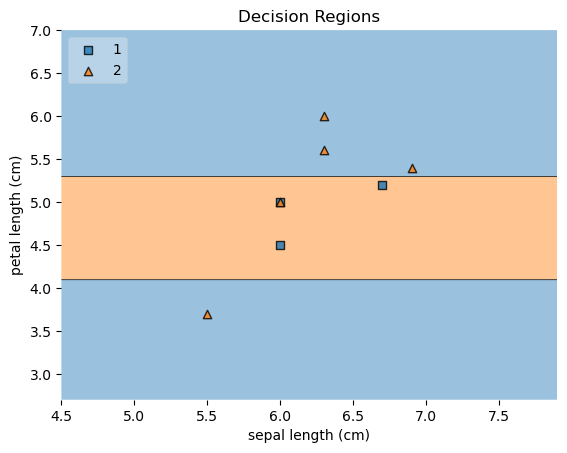

Accuracy: 60.00%


c:\Users\bhara\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [224]:
df_bag = df_train.sample(8, replace=True)
X_bag = df_bag.iloc[:,0:2]
y_bag = df_bag.iloc[:,-1]
print(X_bag.shape)
print(y_bag.shape)
print(df_bag)
clf3 = DecisionTreeClassifier()
evaluate_model(clf3, x_bag, y_bag)

## prediction / Aggregation 

In [226]:
df_test

,sepal length (cm),petal length (cm),target
62,6.0,4.0,1
124,6.7,5.7,2
108,6.7,5.8,2
93,5.0,3.3,1
75,6.6,4.4,1


In [227]:
print("classifier 1 : " + str(clf1.predict(np.array([6.0, 4.0]).reshape(1, 2))))
print("classifier 2 : " + str(clf2.predict(np.array([6.0, 4.0]).reshape(1, 2))))
print("classifier 3 : " + str(clf3.predict(np.array([6.0, 4.0]).reshape(1, 2))))


classifier 1 : [1]
classifier 2 : [2]
classifier 3 : [2]


c:\Users\bhara\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\bhara\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\bhara\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


## Types of bagging 

### Pasting 
#### without replacing 

In [228]:
df_train

,sepal length (cm),petal length (cm),target
94,5.6,4.2,1
81,5.5,3.7,1
136,6.3,5.6,2
119,6.0,5.0,2
139,6.9,5.4,2
110,6.5,5.1,2
100,6.3,6.0,2
99,5.7,4.1,1
145,6.7,5.2,2
85,6.0,4.5,1


In [249]:
df_train.sample(8)

,sepal length (cm),petal length (cm),target
100,6.3,6.0,2
99,5.7,4.1,1
136,6.3,5.6,2
145,6.7,5.2,2
94,5.6,4.2,1
110,6.5,5.1,2
119,6.0,5.0,2
139,6.9,5.4,2


### Random subspaces  // column sampling

In [231]:
df = load_iris()
X = df.data
y = df.target
df = pd.DataFrame(X, columns=df.feature_names)
df['target'] = y
df.head()

<IPython.core.display.Javascript object>

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [232]:
df1 = df.sample(10)

In [233]:
df1

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
142,5.8,2.7,5.1,1.9,2
105,7.6,3.0,6.6,2.1,2
141,6.9,3.1,5.1,2.3,2
23,5.1,3.3,1.7,0.5,0
64,5.6,2.9,3.6,1.3,1
7,5.0,3.4,1.5,0.2,0
69,5.6,2.5,3.9,1.1,1
96,5.7,2.9,4.2,1.3,1
20,5.4,3.4,1.7,0.2,0
42,4.4,3.2,1.3,0.2,0


In [246]:
df1.sample(2, replace=True,axis=1)

,sepal length (cm),petal length (cm)
142,5.8,5.1
105,7.6,6.6
141,6.9,5.1
23,5.1,1.7
64,5.6,3.6
7,5.0,1.5
69,5.6,3.9
96,5.7,4.2
20,5.4,1.7
42,4.4,1.3


### Random patches // Both row and column sampling 

In [236]:
df1

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
142,5.8,2.7,5.1,1.9,2
105,7.6,3.0,6.6,2.1,2
141,6.9,3.1,5.1,2.3,2
23,5.1,3.3,1.7,0.5,0
64,5.6,2.9,3.6,1.3,1
7,5.0,3.4,1.5,0.2,0
69,5.6,2.5,3.9,1.1,1
96,5.7,2.9,4.2,1.3,1
20,5.4,3.4,1.7,0.2,0
42,4.4,3.2,1.3,0.2,0


In [243]:
df1.sample(8,replace=True,axis=0).sample(2, replace=True,axis=1)

,petal length (cm),sepal width (cm)
7,1.5,3.4
142,5.1,2.7
7,1.5,3.4
141,5.1,3.1
69,3.9,2.5
23,1.7,3.3
142,5.1,2.7
23,1.7,3.3
